In [29]:
import pandas as pd
import openpyxl

# Données Générales

In [ ]:
communes = pd.read_csv("../data/raw/communes-france-2025.csv", sep=";")
# Selectionner les villes à garder
ville_1 = "Colombes"
ville_2 = "Angers"

communes_a_garder = communes[communes["nom_standard"].isin([ville_1, ville_2])]
communes_a_garder.head()

C:\Users\alice\AppData\Local\Temp\ipykernel_31100\2823309677.py:1: DtypeWarning: Columns (0: code_insee, 1: dep_code, 2: canton_code, 3: epci_code, 4: code_insee_centre_zone_emploi, 5: code_unite_urbaine) have mixed types. Specify dtype option on import or set low_memory=False.
  communes = pd.read_csv("../data/raw/communes-france-2025.csv", sep=";")


,code_insee,nom_standard,nom_sans_pronom,nom_a,nom_de,nom_sans_accent,nom_standard_majuscule,typecom,typecom_texte,reg_code,...,longitude_mairie,latitude_centre,longitude_centre,grille_densite,grille_densite_texte,niveau_equipements_services,niveau_equipements_services_texte,gentile,url_wikipedia,url_villedereve
17513,49007,Angers,Angers,à Angers,d'Angers,angers,ANGERS,COM,commune,52,...,-0.548,47.477,-0.556,1,Grands centres urbains,4.0,centres majeurs d'équipements et de services,Angevins,https://fr.wikipedia.org/wiki/fr:Angers,https://villedereve.fr/ville/49007-angers
34511,92025,Colombes,Colombes,à Colombes,de Colombes,colombes,COLOMBES,COM,commune,11,...,2.254,48.922,2.247,1,Grands centres urbains,3.0,centres structurants d'équipements et de services,Colombiens,https://fr.wikipedia.org/wiki/fr:Colombes,https://villedereve.fr/ville/92025-colombes


# Web Scrapping Ville de Reve

In [ ]:
from selenium import webdriver
from selenium.webdriver.common.by import By
from webdriver_manager.chrome import ChromeDriverManager
from selenium.webdriver.chrome.service import Service

data_list = []   # <-- IMPORTANT : en dehors de la boucle

for ville in [ville_1, ville_2]:
    url = f"https://villedereve.fr/ville/{communes_a_garder[communes_a_garder['nom_standard'] == ville]['code_insee'].values[0]}-{ville.lower()}"

    # Lancer Chrome automatiquement
    driver = webdriver.Chrome(service=Service(ChromeDriverManager().install()))
    driver.get(url)

    # Récupérer le score
    score_element = driver.find_element(By.CSS_SELECTOR, "#city-score h3")
    score = score_element.text.strip()
    score = score + "100"
    print("Score :", score)

    # Récupérer les descriptions
    description_elements = driver.find_elements(By.CSS_SELECTOR, "p.description")
    descriptions = [desc.text.strip() for desc in description_elements]
    print("Descriptions :", descriptions)

    # Stocker dans un dictionnaire
    ville_data = {
        "ville": ville,
        "score": score,
        "presentation": descriptions
    }

    # Ajouter à la liste globale
    data_list.append(ville_data)

    driver.quit()

# Transformer la liste en DataFrame
df_villes = pd.DataFrame(data_list)

# left joindre les table communes_a_garder et df_villes sur la colonne "ville" et "nom_standard"
df_final = pd.merge(communes_a_garder, df_villes, left_on="nom_standard", right_on="ville", how="left")
df_final.head()
# exporter le dataframe final en xlsx
df_final.to_excel("../data/processed/donnees_generale_filtrer.xlsx", index=False)


Score : 53.6/100
Descriptions : ["Colombes est une commune du nord de la France, dans le département des Hauts-de-Seine et la région d'Île-de-France. Il s'agit d'une ville intermédiaire de 91 050 habitants située au nord-ouest de la ville de Paris à 58 km au sud de Beauvais et 69 km au sud-ouest de Compiègne. La ville fait partie d'une agglomération de 430 communes et 13 123 000 habitants.", 'En 2026, Colombes a un score général de 53.6 / 100. Elle est 99ᵉ / 113 du palmarès des villes intermédiaires en 2026.', "Il s'agit de la 4ᵉ ville la plus peuplée des Hauts-de-Seine."]
Score : 82.2/100
Descriptions : ["Angers est une commune de l'ouest de la France, dans le département du Maine-et-Loire et la région des Pays de la Loire. Il s'agit d'une grande ville de 159 000 habitants. La commune est au coeur d'une agglomération de 253 000 habitants.", 'En 2026, Angers a un score général de 82.2 / 100. Elle est 1ᵉ / 21 du palmarès des grandes villes en 2026 et 28ᵉ du classement de toutes les vill

,ville,score,presentation
0,Colombes,53.6/100,[Colombes est une commune du nord de la France...
1,Angers,82.2/100,[Angers est une commune de l'ouest de la Franc...


# API Données Météo

In [54]:
import requests
import pandas as pd
from datetime import datetime, timedelta

ville_1 = "Colombes"
ville_2 = "Angers"

# Récupération des coordonnées 
coords = {
    row["nom_standard"]: (row["latitude_mairie"], row["longitude_mairie"])
    for _, row in df_final.iterrows()
}




today = datetime.today().date()
one_year_ago = today - timedelta(days=365)

start = one_year_ago.strftime("%Y-%m-%d")
end = today.strftime("%Y-%m-%d")

variables = "temperature_2m,relativehumidity_2m,wind_speed_10m,precipitation"

dfs = {}

for ville in [ville_1, ville_2]:
    lat, lon = coords[ville]

    url = (
        "https://archive-api.open-meteo.com/v1/archive?"
        f"latitude={lat}&longitude={lon}"
        f"&start_date={start}&end_date={end}"
        f"&hourly={variables}"
    )

    data = requests.get(url).json()

    df = pd.DataFrame(data["hourly"])
    df["datetime"] = pd.to_datetime(df["time"])
    df["ville"] = ville

    dfs[ville] = df

df_ville_1 = dfs[ville_1]
df_ville_2 = dfs[ville_2]
# fusionner les deux dataframes
meteo_df = pd.concat([df_ville_1, df_ville_2], ignore_index=True)
meteo_df.head()
meteo_df.to_excel("../data/processed/donnees_open_meteo.xlsx", index=False)

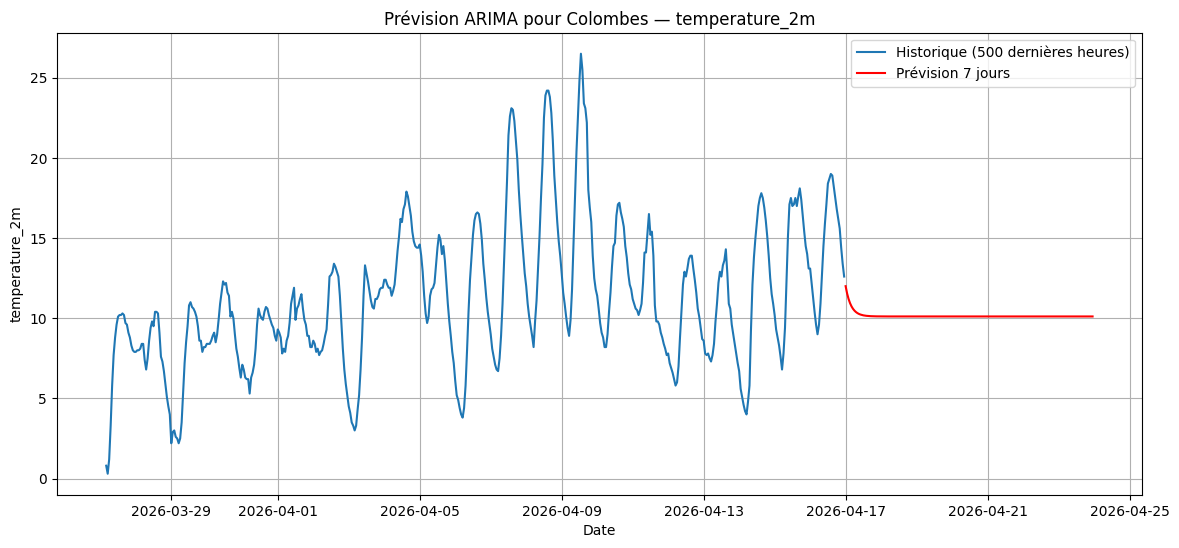

2026-04-17 00:00:00    11.999845
2026-04-17 01:00:00    11.544382
2026-04-17 02:00:00    11.198726
2026-04-17 03:00:00    10.936405
2026-04-17 04:00:00    10.737327
Freq: h, dtype: float64

In [18]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA

# On choisit une ville et une variable
ville_cible = "Colombes"
variable = "temperature_2m"

# Filtrer la ville
df_city = df_villes[df_villes["ville"] == ville_cible].copy()

# Mettre datetime en index
df_city = df_city.set_index("datetime")

# Garder uniquement la variable
ts = df_city[variable].astype(float)

# Vérifier qu'il n'y a pas de trous
ts = ts.asfreq("h").interpolate()

# Ajuster un modèle ARIMA simple (1,1,1)
model = ARIMA(ts, order=(1,1,1))
model_fit = model.fit()

# Prévoir 7 jours = 7 * 24 heures
steps = 7 * 24
forecast = model_fit.forecast(steps=steps)

# Créer un index temporel pour la prévision
forecast_index = pd.date_range(start=ts.index[-1], periods=steps+1, freq="h")[1:]
forecast = pd.Series(forecast.values, index=forecast_index)

# Affichage
plt.figure(figsize=(14,6))
plt.plot(ts[-500:], label="Historique (500 dernières heures)")
plt.plot(forecast, label="Prévision 7 jours", color="red")
plt.title(f"Prévision ARIMA pour {ville_cible} — {variable}")
plt.xlabel("Date")
plt.ylabel(variable)
plt.legend()
plt.grid()
plt.show()

forecast.head()


# Education

In [ ]:
education = pd.read_csv("../data/raw/annuaire-de-l-education.csv", sep=";")
education = education[["Identifiant_de_l_etablissement", "Nom_etablissement", "Type_etablissement", "Statut_public_prive","Adresse_1","Code_postal","Code_commune","Nom_commune","Code_departement","Ecole_maternelle",	"Ecole_elementaire"	,"Voie_generale"	,"Voie_technologique",	"Voie_professionnelle",	"Telephone","Web","Mail",	"Restauration",	"Hebergement",	"ULIS",	"Apprentissage",	"Segpa"	,"Section_arts"	,"Section_cinema",	"Section_theatre",	"Section_sport",	"Section_internationale",	"Section_europeenne",	"Lycee_Agricole",	"Lycee_militaire",	"Lycee_des_metiers",	"Post_BAC","position",	"Libelle_departement",	"Libelle_academie",	"Libelle_region","date_ouverture"]]

education_a_garder = education[education["Nom_commune"].isin([ville_1, ville_2])]

education_a_garder.head()
education_a_garder.to_excel("../data/processed/education_filtrer.xlsx", index=False)

C:\Users\alice\AppData\Local\Temp\ipykernel_31100\1263813514.py:1: DtypeWarning: Columns (0: rpi_disperse, 1: Code_type_contrat_prive) have mixed types. Specify dtype option on import or set low_memory=False.
  education = pd.read_csv("../data/raw/annuaire-de-l-education.csv", sep=";")


# Tourisme (a revoir)

In [19]:
import requests
import time

API_KEY = "4c775015-0f12-4366-bc70-d8dbe0404ec0"
BASE_URL = "https://api.datatourisme.fr/v1/catalog"

headers = {
    "X-API-Key": API_KEY
}

params = {
    "filters": "isLocatedAt.address.hasAddressCity.insee=75056",
    "page_size": 100
}

all_poi = []
url = BASE_URL

while url:
    r = requests.get(url, headers=headers, params=params)
    data = r.json()

    all_poi.extend(data["objects"])
    url = data["meta"]["next"]   # pagination officielle ✅
    params = None                # IMPORTANT : next contient déjà les params

    time.sleep(0.1)              # respect quotas

print(f"{len(all_poi)} POI récupérés")

KeyError: 'next'